In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_parquet("../data/processed/transactions_clean.parquet")
df["line_total"] = df["Quantity"] * df["Price"]
print(df.shape, df["Customer_ID"].nunique(), "customers")

(790721, 10) 5852 customers


In [3]:
# Analysis date = day after the last transaction in the data
ANALYSIS_DATE = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Analysis date:", ANALYSIS_DATE)

Analysis date: 2011-12-10 12:50:00


In [4]:
# --- RFM ---
per_invoice = df.groupby(["Customer_ID", "Invoice"]).agg(
    invoice_date=("InvoiceDate", "max"),
    invoice_total=("line_total", "sum"),
    n_items=("StockCode", "size"),
).reset_index()

rfm = per_invoice.groupby("Customer_ID").agg(
    recency=("invoice_date", lambda s: (ANALYSIS_DATE - s.max()).days),
    frequency=("Invoice", "nunique"),
    monetary=("invoice_total", "sum"),
)
rfm.describe()

,recency,frequency,monetary
count,5852.000000,5852.000000,5852.000000
mean,200.198052,6.253247,2969.392491
std,208.509570,12.749286,14599.308267
min,1.000000,1.000000,2.950000
25%,25.000000,1.000000,343.115000
50%,95.000000,3.000000,874.875000
75%,379.000000,7.000000,2281.620000
max,739.000000,373.000000,608821.650000


In [5]:
# --- Extra features ---
extras = df.groupby("Customer_ID").agg(
    category_diversity=("StockCode", "nunique"),
)
extras["avg_basket_size"] = per_invoice.groupby("Customer_ID")["n_items"].mean()

is_intl = df.groupby("Customer_ID")["Country"].agg(lambda s: (s != "United Kingdom").any())
extras["is_international"] = is_intl.astype(int)

extras.describe()

,category_diversity,avg_basket_size,is_international
count,5852.000000,5852.000000,5852.000000
mean,82.192071,21.936070,0.088517
std,116.501436,19.244518,0.284069
min,1.000000,1.000000,0.000000
25%,19.000000,10.000000,0.000000
50%,45.000000,17.500000,0.000000
75%,103.000000,27.783333,0.000000
max,2546.000000,299.705882,1.000000


In [6]:
features = rfm.join(extras)
features.head()

,recency,frequency,monetary,category_diversity,avg_basket_size,is_international
Customer_ID,,,,,,
12346,326,3,77352.96,25,8.333333,0
12347,2,8,5633.32,126,31.625000,1
12348,75,5,1658.40,24,9.200000,1
12349,19,3,3678.69,137,57.333333,1
12350,310,1,294.40,16,16.000000,1


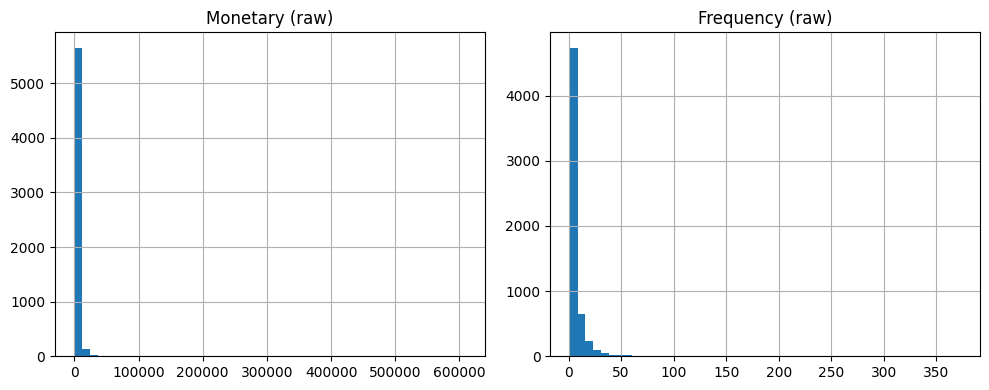

In [7]:
# Confirm the skew before transforming
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
features["monetary"].hist(bins=50, ax=axes[0])
axes[0].set_title("Monetary (raw)")
features["frequency"].hist(bins=50, ax=axes[1])
axes[1].set_title("Frequency (raw)")
plt.tight_layout()
plt.show()

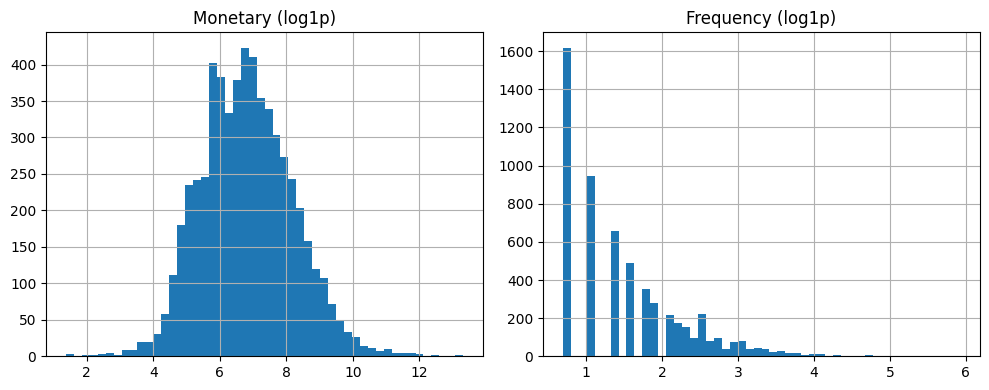

In [8]:

features_log = features.copy()
features_log["monetary"] = np.log1p(features_log["monetary"])
features_log["frequency"] = np.log1p(features_log["frequency"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
features_log["monetary"].hist(bins=50, ax=axes[0])
axes[0].set_title("Monetary (log1p)")
features_log["frequency"].hist(bins=50, ax=axes[1])
axes[1].set_title("Frequency (log1p)")
plt.tight_layout()
plt.show()

In [9]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(features_log),
    columns=features_log.columns,
    index=features_log.index,
)
X_scaled.describe()

,recency,frequency,monetary,category_diversity,avg_basket_size,is_international
count,5.852000e+03,5.852000e+03,5.852000e+03,5.852000e+03,5.852000e+03,5.852000e+03
mean,-2.306957e-17,3.678989e-16,-1.121910e-15,3.551499e-17,-4.856751e-17,-1.942701e-17
std,1.000085e+00,1.000085e+00,1.000085e+00,1.000085e+00,1.000085e+00,1.000085e+00
min,-9.554241e-01,-1.057348e+00,-3.936783e+00,-6.969786e-01,-1.087991e+00,-3.116294e-01
25%,-8.403117e-01,-1.057348e+00,-7.088527e-01,-5.424609e-01,-6.202852e-01,-3.116294e-01
50%,-5.045670e-01,-1.991557e-01,-3.378893e-02,-3.192686e-01,-2.305305e-01,-3.116294e-01
75%,8.575972e-01,6.590367e-01,6.583336e-01,1.786219e-01,3.038664e-01,-3.116294e-01
max,2.584284e+00,5.419339e+00,4.694784e+00,2.115011e+01,1.443494e+01,3.208940e+00


In [10]:
OUT_DIR = Path("../data/processed")
features.to_parquet(OUT_DIR / "rfm_features.parquet")       # raw, for persona writeup later
X_scaled.to_parquet(OUT_DIR / "rfm_features_scaled.parquet") # for clustering
print("Saved.")

Saved.
